# Cell A (10 C) prediction via GP gap-correction

Trust PyBaMM for the physics, predict the gap between simulation and experiment
on Cells D (25 C) and F (40 C), then carry that gap to Cell A using a Gaussian
Process with temperature as 1/T.

1. SoH vs ageing cycles and vs charge throughput (Matern-5/2)
2. LLI / LAM_NE_Si / LAM_PE vs charge throughput (mechanism-split, sqrt trend)
3. Same modes with an RBF x Linear kernel, no sqrt trend
4. Kernel comparison for SoH: RBF, Matern-5/2, Matern-3/2, RBF x Linear

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, DotProduct, ConstantKernel, WhiteKernel

SIM_DIR = r"D:\Mtech\Battery (MTP)\Stage 2\Output Exp Data\kirkaldy pybamm\sim_output_7\Summary Data\Performance Summary"
EXP_DIR = r"D:\Mtech\Battery (MTP)\Stage 2\Data\IMP_1\Expt 5 - Standard Cycle Aging (Control)\exp_output_1\Summary Data_Exp\Performance Summary_Exp"

CELL_TAG = {
    "A": "A (10degC)", "B": "B (10degC)", "C": "C (10degC)",
    "D": "D (25degC)", "E": "E (25degC)",
    "F": "F (40degC)", "G": "G (40degC)", "H": "H (40degC)",
}
SIM_NAME = "Sim 5 - cell {tag} - Processed Data.csv"
EXP_NAME = "Expt 5 - cell {tag} - Processed Data.csv"
TEMP_K = {"A": 289.45, "D": 301.75, "F": 314.75}
TRAIN_CELLS = ["D", "F"]
TARGET_CELL = "A"
EOL = 0.80

def sim_path(c): return os.path.join(SIM_DIR, SIM_NAME.format(tag=CELL_TAG[c]))
def exp_path(c): return os.path.join(EXP_DIR, EXP_NAME.format(tag=CELL_TAG[c]))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))

## Part 1 — SoH delta-learning

Same function for both x-axes (ageing cycles, charge throughput): build the gap
on D and F, fit a Matern-5/2 ARD GP, predict A, cross-check with a plain
Arrhenius interpolation, score against the real A experiment.

In [2]:
def soh_delta_predict(x_col, out_csv, out_png, title):
    def load(path):
        df = pd.read_csv(path)[[x_col, "SoH"]].dropna().sort_values(x_col)
        return df[x_col].to_numpy(float), df["SoH"].to_numpy(float)

    def gap_curve(cell):
        qe, se = load(exp_path(cell))
        qs, ss = load(sim_path(cell))
        son = np.interp(qe, qs, ss)
        return qe, se - son, se, son

    train_X, train_y, records = [], [], {}
    for cell in TRAIN_CELLS:
        qv, gap, se, son = gap_curve(cell)
        invT = 1.0 / TEMP_K[cell]
        train_X.append(np.column_stack([qv, np.full_like(qv, invT)]))
        train_y.append(gap)
        records[cell] = dict(q=qv, exp=se, sim=son, gap=gap)
    X = np.vstack(train_X); y = np.concatenate(train_y)
    xm, xsd = X.mean(0), X.std(0); Xs = (X - xm) / xsd
    ym = y.mean(); ys = y - ym

    kernel = ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=2.5) + WhiteKernel(1e-4)
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=False,
                                  n_restarts_optimizer=10, random_state=0).fit(Xs, ys)

    qA, sA = load(sim_path(TARGET_CELL))
    invTA = 1.0 / TEMP_K[TARGET_CELL]
    XAs = (np.column_stack([qA, np.full_like(qA, invTA)]) - xm) / xsd
    gm, gsd = gp.predict(XAs, return_std=True); gm += ym
    pred, lo, hi = sA + gm, sA + gm - 2 * gsd, sA + gm + 2 * gsd

    gapD = np.interp(qA, records["D"]["q"], records["D"]["gap"])
    gapF = np.interp(qA, records["F"]["q"], records["F"]["gap"])
    iD, iF = 1.0 / TEMP_K["D"], 1.0 / TEMP_K["F"]
    fac = (invTA - iD) / (iF - iD)
    arrh = sA + (gapD + (gapF - gapD) * fac)

    score = ""
    try:
        qAe, sAe = load(exp_path(TARGET_CELL))
        pe = np.interp(qAe, qA, pred); se_ = np.interp(qAe, qA, sA)
        loe, hie = np.interp(qAe, qA, lo), np.interp(qAe, qA, hi)
        rs, rg = rmse(se_, sAe), rmse(pe, sAe)
        inside = np.mean((sAe >= loe) & (sAe <= hie)) * 100
        score = (f"RMSE raw PyBaMM : {rs:.4f}\nRMSE GP pred    : {rg:.4f}\n"
                 f"In 95% band     : {inside:.0f}%")
        print(title); print(score)
    except FileNotFoundError:
        print(title, "- no Cell A experiment found")

    pd.DataFrame({x_col: qA, "A_sim": sA, "A_pred_GP": pred,
                  "A_lo95": lo, "A_hi95": hi, "A_arrhenius": arrh}).to_csv(out_csv, index=False)

    colors = {"A": "#1f5fbf", "D": "#1a8a1a", "F": "#c0392b"}
    plt.figure(figsize=(10, 6))
    for cell in TRAIN_CELLS:
        r, c = records[cell], colors[cell]
        plt.plot(r["q"], r["exp"], "-o", color=c, ms=4, label=f"{cell} exp")
        plt.plot(r["q"], r["sim"], "--s", color=c, ms=3, alpha=0.6, label=f"{cell} sim")
    plt.plot(qA, sA, "--s", color=colors["A"], ms=3, alpha=0.6, label="A sim")
    plt.fill_between(qA, lo, hi, color=colors["A"], alpha=0.18, label="A 95% band")
    plt.plot(qA, pred, "-", color=colors["A"], lw=2.5, label="A predicted (GP)")
    try:
        plt.plot(qAe, sAe, "x", color="black", ms=8, mew=2, label="A exp (measured)")
    except NameError:
        pass
    plt.axhline(EOL, color="gray", ls=":", lw=1)
    plt.text(qA.min() + 5, EOL + 0.004, "80% EOL", color="gray", fontsize=9)
    plt.xlabel(x_col); plt.ylabel("SoH"); plt.title(title)
    plt.legend(fontsize=8, ncol=2)
    if score:
        plt.gcf().text(0.13, 0.16, score, fontsize=8, family="monospace",
                       bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
    plt.tight_layout(); plt.savefig(out_png, dpi=150)
    plt.show()
    return dict(qA=qA, pred=pred)

Run for ageing cycles and for charge throughput.

D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Cell A (10 C) SoH prediction vs ageing cycles: GP model
RMSE raw PyBaMM : 0.0492
RMSE GP pred    : 0.0080
In 95% band     : 100%


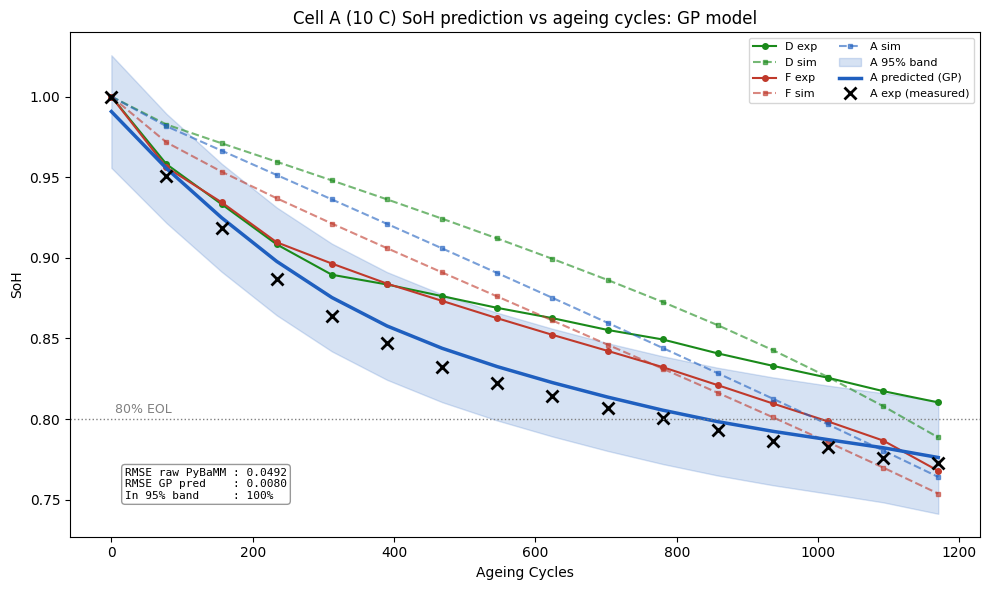

In [3]:
_ = soh_delta_predict("Ageing Cycles", "cellA_SoH_vsCycle.csv", "cellA_SoH_vsCycle.png",
                      "Cell A (10 C) SoH prediction vs ageing cycles: GP model")

D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Cell A (10 C) SoH prediction vs charge throughput: GP model
RMSE raw PyBaMM : 0.0586
RMSE GP pred    : 0.0079
In 95% band     : 100%


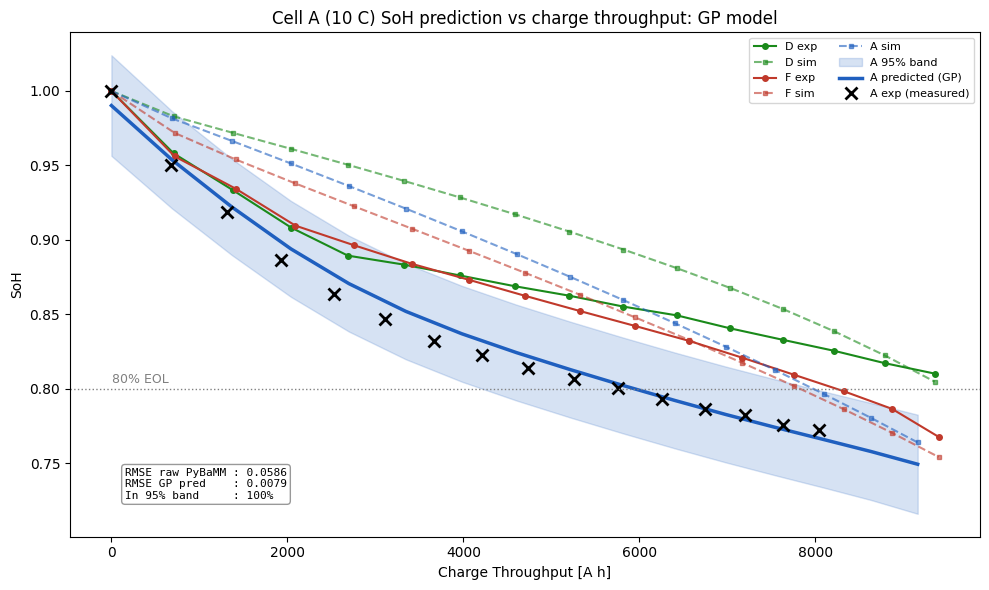

In [4]:
_ = soh_delta_predict("Charge Throughput [A h]", "cellA_SoH_vsQ.csv", "cellA_SoH_vsQ.png",
                      "Cell A (10 C) SoH prediction vs charge throughput: GP model")

## Part 2 — LLI, LAM_NE_Si, LAM_PE vs charge throughput

Multi-cell training (D+E at 25 C, F+G+H at 40 C). A linear trend in
(throughput, 1/T) carries the mean; a GP on the residual carries the
curvature. `trend` and `kernel_factory` are arguments so the Matern/sqrt
version and the RBF x Linear/raw version share one function.

In [5]:
TRAIN_GROUPS = {
    "25C": dict(T=301.75, exp_cells=["D", "E"],      sim_cell="D"),
    "40C": dict(T=314.75, exp_cells=["F", "G", "H"], sim_cell="F"),
}
TARGETS = {"LLI": "LLI", "LAM_NE_Si": "LAM NE_Si", "LAM_PE": "LAM PE"}
XMAX_AH = 6000.0
QCOL = "Charge Throughput [A h]"

def load_q(path, cols):
    df = pd.read_csv(path)[[QCOL] + cols].copy()
    return df.dropna(subset=[QCOL]).sort_values(QCOL).reset_index(drop=True)

cols = list(TARGETS.values())
SIM = {g["sim_cell"]: load_q(sim_path(g["sim_cell"]), cols) for g in TRAIN_GROUPS.values()}
SIM[TARGET_CELL] = load_q(sim_path(TARGET_CELL), cols)
EXP = {}
for g in TRAIN_GROUPS.values():
    for c in g["exp_cells"]:
        try:
            EXP[c] = load_q(exp_path(c), cols)
        except FileNotFoundError:
            print(f"  (skipping missing exp cell {c})")
EXP[TARGET_CELL] = load_q(exp_path(TARGET_CELL), cols)

def coord(q, trend):
    return np.sqrt(np.clip(q, 0, None)) if trend == "sqrt" else np.asarray(q, float)

def design(u, t):
    return np.column_stack([np.ones_like(u), u, t, u * t])

def fit_predict_one(target_col, trend, kernel_factory):
    u_all, t_all, gap_all, rec = [], [], [], {}
    for gname, g in TRAIN_GROUPS.items():
        qs = SIM[g["sim_cell"]][QCOL].to_numpy(float)
        vs = SIM[g["sim_cell"]][target_col].to_numpy(float)
        rec[gname] = dict(sim_x=qs, sim_v=vs, cells={})
        for c in g["exp_cells"]:
            if c not in EXP:
                continue
            qe = EXP[c][QCOL].to_numpy(float)
            ve = EXP[c][target_col].to_numpy(float)
            gap = ve - np.interp(qe, qs, vs)
            u_all.append(coord(qe, trend)); t_all.append(np.full_like(qe, 1.0 / g["T"]))
            gap_all.append(gap); rec[gname]["cells"][c] = dict(x=qe, exp=ve)

    u = np.concatenate(u_all); t = np.concatenate(t_all); gap = np.concatenate(gap_all)
    F = np.column_stack([u, t]); mu, sd = F.mean(0), F.std(0)
    us, ts = (u - mu[0]) / sd[0], (t - mu[1]) / sd[1]
    Dtr = design(us, ts); beta, *_ = np.linalg.lstsq(Dtr, gap, rcond=None)
    resid = gap - Dtr @ beta

    gp = GaussianProcessRegressor(kernel=kernel_factory(), normalize_y=True,
                                  n_restarts_optimizer=12, random_state=0
                                  ).fit(np.column_stack([us, ts]), resid)

    qA = SIM[TARGET_CELL][QCOL].to_numpy(float)
    sA = SIM[TARGET_CELL][target_col].to_numpy(float)
    usA = (coord(qA, trend) - mu[0]) / sd[0]
    tsA = np.full_like(qA, (1.0 / TEMP_K[TARGET_CELL] - mu[1]) / sd[1])
    pred = sA + design(usA, tsA) @ beta + gp.predict(np.column_stack([usA, tsA]))
    i0 = int(np.argmin(qA)); pred[i0] = 0.0

    qAe = EXP[TARGET_CELL][QCOL].to_numpy(float)
    vAe = EXP[TARGET_CELL][target_col].to_numpy(float)
    m = qAe <= XMAX_AH
    rm = lambda a, b: rmse(a, b) if np.any(m) else float("nan")
    return dict(x=qA, sim=sA, pred=pred, xexp=qAe, vexp=vAe, rec=rec,
                rmse_sim=rm(np.interp(qAe[m], qA, sA), vAe[m]),
                rmse_gp =rm(np.interp(qAe[m], qA, pred), vAe[m]))

def plot_3panel(results, title, out_png):
    gcol = {"25C": "#1a8a1a", "40C": "#c0392b"}
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    for ax, (short, r) in zip(axes, results.items()):
        for gname, g in r["rec"].items():
            ax.plot(g["sim_x"], g["sim_v"], "--", color=gcol[gname], alpha=0.55, lw=1.4,
                    label=f"{gname} sim")
            for c, cc in g["cells"].items():
                ax.plot(cc["x"], cc["exp"], "-o", color=gcol[gname], ms=2.5, alpha=0.8)
        ax.plot(r["x"], r["sim"], "--s", color="#1f5fbf", ms=2.5, alpha=0.6, label="A raw PyBaMM")
        ax.plot(r["x"], r["pred"], "-", color="#1f5fbf", lw=2.2, label="A predicted (GP)")
        ax.plot(r["xexp"], r["vexp"], "x", color="black", ms=6, mew=1.6, label="A exp")
        ax.set_xlim(0, XMAX_AH); ax.set_title(short, fontsize=11)
        ax.set_xlabel(QCOL); ax.set_ylabel("fraction lost")
        txt = f"RMSE raw PyBaMM: {r['rmse_sim']:.4f}\nRMSE GP model:   {r['rmse_gp']:.4f}"
        ax.text(0.03, 0.97, txt, transform=ax.transAxes, fontsize=8, family="monospace",
                va="top", ha="left", bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.85))
    axes[0].legend(fontsize=7, ncol=2, loc="lower right")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.93]); fig.savefig(out_png, dpi=150)
    plt.show()

def plot_separate(results, out_png_map):
    gcol = {"25C": "#1a8a1a", "40C": "#c0392b"}
    for short, r in results.items():
        fig, ax = plt.subplots(figsize=(6.2, 4.6))
        for gname, g in r["rec"].items():
            ax.plot(g["sim_x"], g["sim_v"], "--", color=gcol[gname], alpha=0.55, lw=1.4,
                    label=f"{gname} sim")
            for c, cc in g["cells"].items():
                ax.plot(cc["x"], cc["exp"], "-o", color=gcol[gname], ms=2.5, alpha=0.8)
        ax.plot(r["x"], r["sim"], "--s", color="#1f5fbf", ms=2.5, alpha=0.6, label="A raw PyBaMM")
        ax.plot(r["x"], r["pred"], "-", color="#1f5fbf", lw=2.2, label="A predicted (GP)")
        ax.plot(r["xexp"], r["vexp"], "x", color="black", ms=6, mew=1.6, label="A exp")
        ax.set_xlim(0, XMAX_AH); ax.set_xlabel(QCOL); ax.set_ylabel("fraction lost")
        ax.set_title(f"Cell A : {short}  vs charge throughput", fontsize=11)
        txt = f"RMSE raw PyBaMM: {r['rmse_sim']:.4f}\nRMSE GP model:   {r['rmse_gp']:.4f}"
        ax.text(0.03, 0.97, txt, transform=ax.transAxes, fontsize=8, family="monospace",
                va="top", ha="left", bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.85))
        ax.legend(fontsize=7, ncol=2, loc="lower right")
        fig.tight_layout(); fig.savefig(out_png_map[short], dpi=150)
        plt.show()

**Matern-5/2 kernel, sqrt-throughput trend** (the original mechanism-split model).

In [6]:
matern_kernel = lambda: (ConstantKernel(1.0, (1e-3, 1e3))
                          * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(0.2, 1e5), nu=2.5)
                          + WhiteKernel(1e-3, (1e-6, 1e0)))

results_matern = {short: fit_predict_one(col, "sqrt", matern_kernel)
                  for short, col in TARGETS.items()}

for short, r in results_matern.items():
    print(f"{short:<12}{r['rmse_sim']:>10.4f}{r['rmse_gp']:>10.4f}")

D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


LLI             0.0782    0.0097
LAM_NE_Si       0.1165    0.0243
LAM_PE          0.0278    0.0074


D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


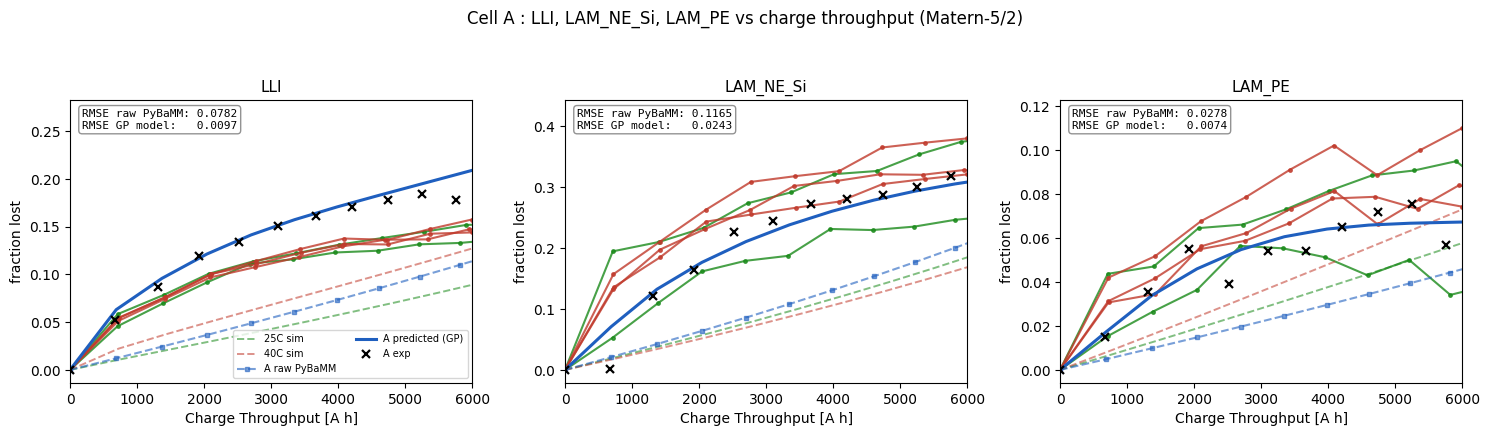

In [7]:
plot_3panel(results_matern, "Cell A : LLI, LAM_NE_Si, LAM_PE vs charge throughput (Matern-5/2)",
            "cellA_LLI_Si_PE_vsQ_matern.png")

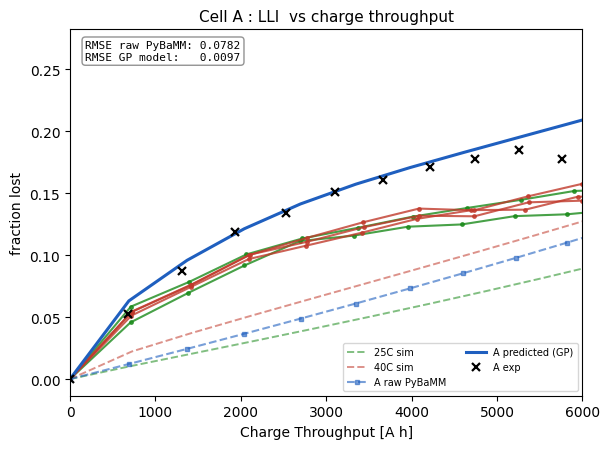

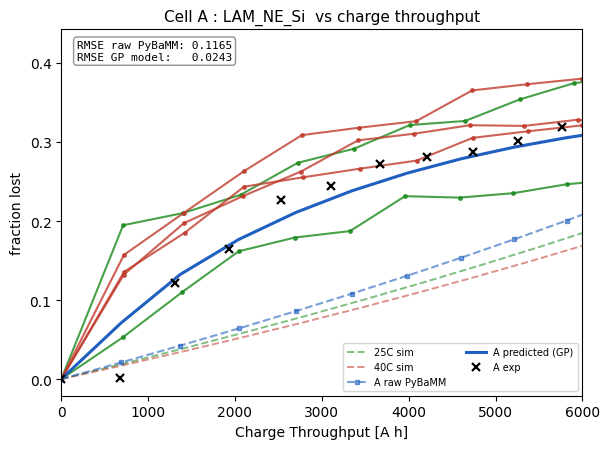

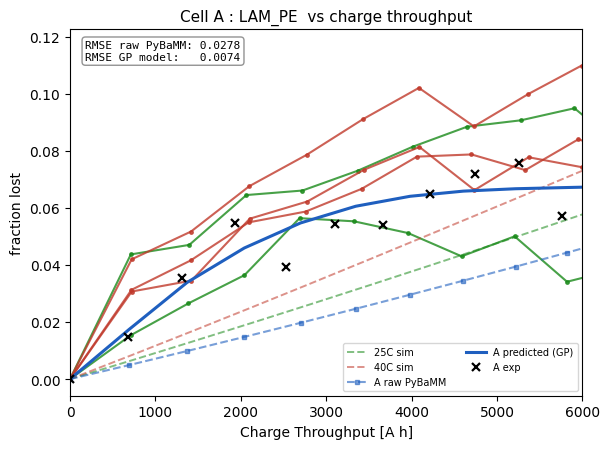

In [8]:
OUT_PNG_MODE = {
    "LLI": "cellA_LLI_vsQ.png", "LAM_NE_Si": "cellA_LAM_NE_Si_vsQ.png", "LAM_PE": "cellA_LAM_PE_vsQ.png",
}
plot_separate(results_matern, OUT_PNG_MODE)

## Part 3 — RBF x Linear kernel, no sqrt trend

Same `fit_predict_one`, swap the kernel and use the raw throughput
(`trend="linear"`) instead of the sqrt coordinate.

In [9]:
rbflin_kernel = lambda: (ConstantKernel(1.0, (1e-3, 1e3))
                          * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(0.1, 1e4))
                          * DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3))
                          + WhiteKernel(1e-3, (1e-6, 1e0)))

results_rbflin = {short: fit_predict_one(col, "linear", rbflin_kernel)
                  for short, col in TARGETS.items()}

for short, r in results_rbflin.items():
    print(f"{short:<12}{r['rmse_sim']:>10.4f}{r['rmse_gp']:>10.4f}")

D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
D:\Other Files\Games\YTT\venv\lib\site-pack

LLI             0.0782    0.0097
LAM_NE_Si       0.1165    0.0200
LAM_PE          0.0278    0.0086


D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


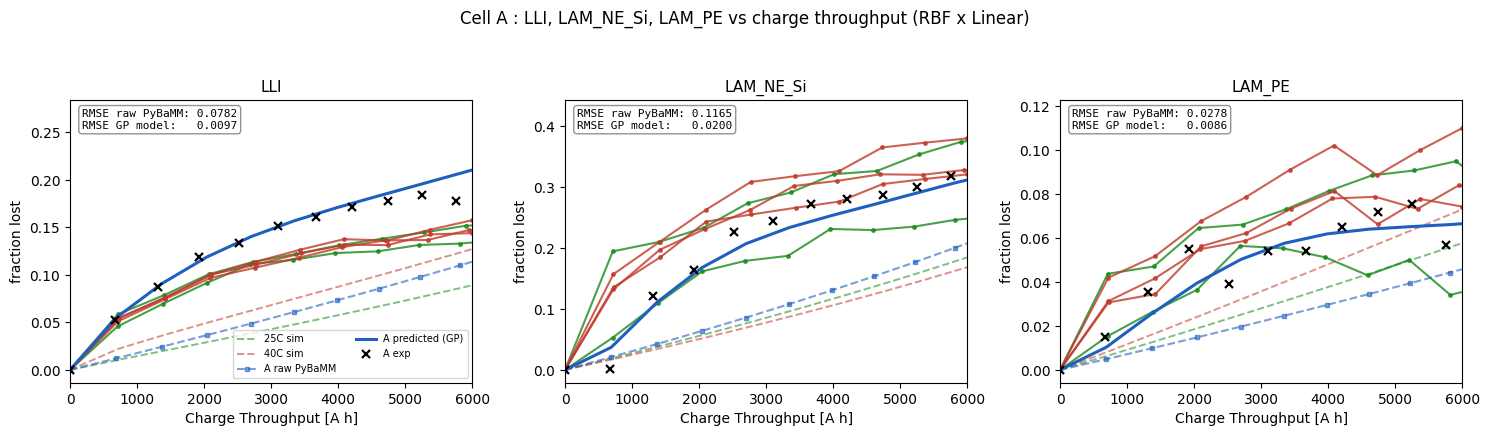

In [10]:
plot_3panel(results_rbflin, "Cell A : LLI, LAM_NE_Si, LAM_PE vs charge throughput (RBF x Linear)",
            "cellA_LLI_Si_PE_vsQ_RBFxLinear.png")

## Part 4 — Kernel comparison for SoH prediction

Four kernels (RBF, Matern-5/2, Matern-3/2, RBF x Linear) trained on the same
D+F gap data, predicting Cell A SoH vs ageing cycles. Same delta-learning idea
as Part 1, looped over kernels instead of fixed to one.

In [11]:
def load_cyc(path):
    df = pd.read_csv(path)[["Ageing Cycles", "SoH"]].dropna().sort_values("Ageing Cycles")
    return df["Ageing Cycles"].to_numpy(float), df["SoH"].to_numpy(float)

def gap_curve_cyc(cell):
    nce, se = load_cyc(exp_path(cell))
    ncs, ss = load_cyc(sim_path(cell))
    son = np.interp(nce, ncs, ss)
    return nce, se - son, se, son

train_X, train_y, records2 = [], [], {}
for cell in TRAIN_CELLS:
    nc, gap, se, son = gap_curve_cyc(cell)
    invT = 1.0 / TEMP_K[cell]
    train_X.append(np.column_stack([nc, np.full_like(nc, invT)]))
    train_y.append(gap); records2[cell] = dict(cycle=nc, exp=se, sim=son)

X = np.vstack(train_X); y = np.concatenate(train_y)
xm, xsd = X.mean(0), X.std(0); Xs = (X - xm) / xsd
ym = y.mean(); ys = y - ym

ncA, sA = load_cyc(sim_path(TARGET_CELL))
invTA = 1.0 / TEMP_K[TARGET_CELL]
XAs = (np.column_stack([ncA, np.full_like(ncA, invTA)]) - xm) / xsd

has_exp = True
try:
    ncAe, sAe = load_cyc(exp_path(TARGET_CELL))
except FileNotFoundError:
    has_exp = False
    print("No Cell A experimental file - RMSE comparison will be skipped.")

KERNELS = [
    ("K1: RBF", "#c0392b",
     lambda: ConstantKernel(1.0) * RBF(length_scale=[1.0, 1.0]) + WhiteKernel(1e-4)),
    ("K2: Matern-5/2", "#1f5fbf",
     lambda: ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=2.5) + WhiteKernel(1e-4)),
    ("K3: Matern-3/2", "#1a8a1a",
     lambda: ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=1.5) + WhiteKernel(1e-4)),
    ("K4: RBF x Linear", "#8e44ad",
     lambda: ConstantKernel(1.0) * RBF(length_scale=[1.0, 1.0]) * DotProduct(sigma_0=0.0) + WhiteKernel(1e-4)),
]

kresults = []
for label, color, kf in KERNELS:
    gp = GaussianProcessRegressor(kernel=kf(), normalize_y=False,
                                  n_restarts_optimizer=10, random_state=0).fit(Xs, ys)
    gm, _ = gp.predict(XAs, return_std=True); gm += ym
    pred = sA + gm
    entry = dict(label=label, color=color, pred=pred)
    if has_exp:
        pe = np.interp(ncAe, ncA, pred); se_ = np.interp(ncAe, ncA, sA)
        entry["rmse_sim"] = rmse(se_, sAe)
        entry["rmse_gp"]  = rmse(pe, sAe)
        print(f"{label:<18}{entry['rmse_sim']:>10.4f}{entry['rmse_gp']:>10.4f}")
    kresults.append(entry)

D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


K1: RBF               0.0492    0.0088


D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


K2: Matern-5/2        0.0492    0.0080


D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))


K3: Matern-3/2        0.0492    0.0114
K4: RBF x Linear      0.0492    0.0085


D:\Other Files\Games\YTT\venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


**Figure: prediction curves for all four kernels (2x2 grid).**

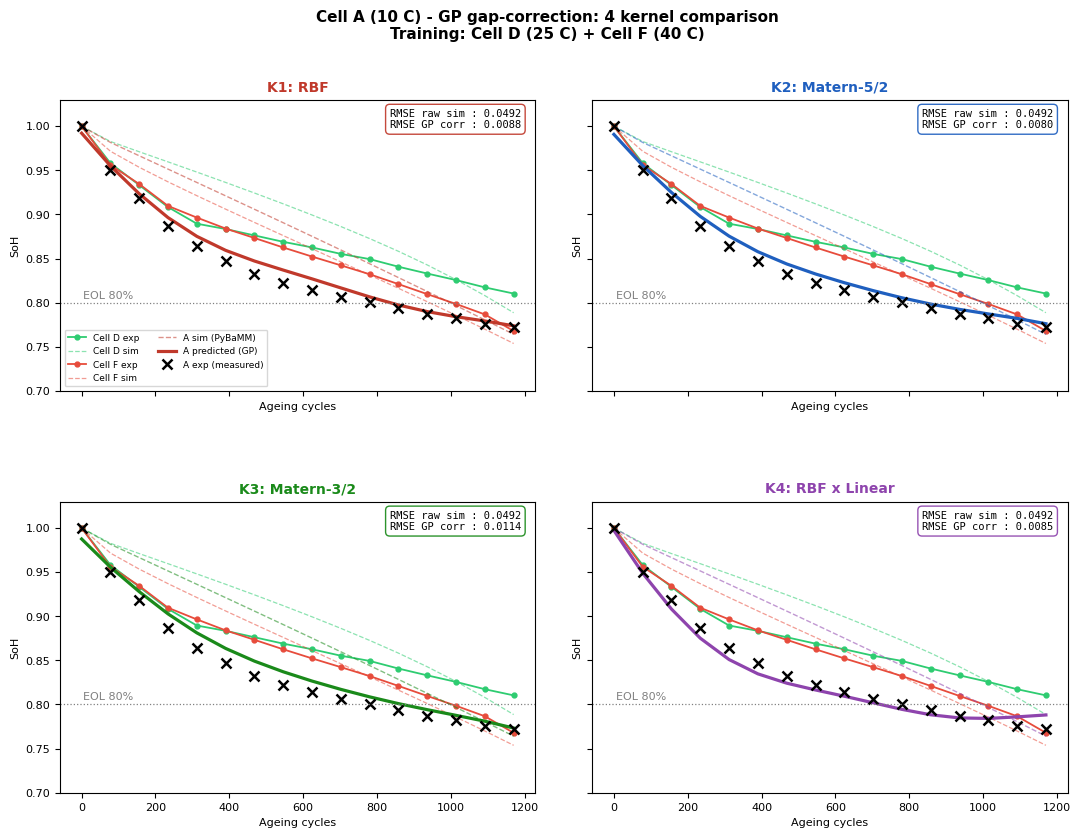

In [12]:
train_colors = {"D": "#2ecc71", "F": "#e74c3c"}

fig1, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
fig1.subplots_adjust(hspace=0.38, wspace=0.12)

for r, ax in zip(kresults, axes.flat):
    color = r["color"]
    for cell in TRAIN_CELLS:
        rc, cc = records2[cell], train_colors[cell]
        ax.plot(rc["cycle"], rc["exp"], "-o", color=cc, ms=3.5, lw=1.3, label=f"Cell {cell} exp")
        ax.plot(rc["cycle"], rc["sim"], "--", color=cc, lw=0.9, alpha=0.55, label=f"Cell {cell} sim")
    ax.plot(ncA, sA, "--", color=color, lw=1.0, alpha=0.55, label="A sim (PyBaMM)")
    ax.plot(ncA, r["pred"], "-", color=color, lw=2.3, label="A predicted (GP)")
    if has_exp:
        ax.plot(ncAe, sAe, "x", color="black", ms=7, mew=1.8, label="A exp (measured)")
    ax.axhline(EOL, color="gray", ls=":", lw=0.9)
    ax.text(ncA.min() + 5, EOL + 0.005, "EOL 80%", color="gray", fontsize=8)
    if has_exp:
        txt = f"RMSE raw sim : {r['rmse_sim']:.4f}\nRMSE GP corr : {r['rmse_gp']:.4f}"
        ax.text(0.97, 0.97, txt, transform=ax.transAxes, fontsize=7.5, family="monospace",
                ha="right", va="top",
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color, lw=1.0, alpha=0.92))
    ax.set_title(r["label"], fontsize=10, fontweight="bold", color=color, pad=6)
    ax.set_xlabel("Ageing cycles", fontsize=8); ax.set_ylabel("SoH", fontsize=8)
    ax.tick_params(labelsize=8); ax.set_ylim(0.70, 1.03)

axes.flat[0].legend(fontsize=6.5, ncol=2, loc="lower left", framealpha=0.9, edgecolor="lightgray")
fig1.suptitle("Cell A (10 C) - GP gap-correction: 4 kernel comparison\nTraining: Cell D (25 C) + Cell F (40 C)",
              fontsize=11, fontweight="bold")
plt.savefig("fig1_cellA_kernel_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure: RMSE bar chart, raw PyBaMM vs GP-corrected, per kernel.**

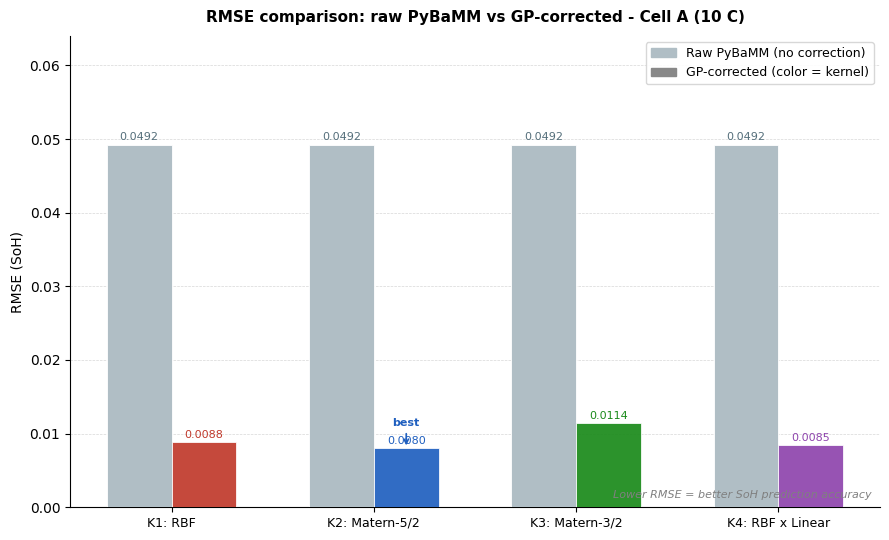

In [13]:
if has_exp:
    rmse_sim_vals = [r["rmse_sim"] for r in kresults]
    rmse_gp_vals  = [r["rmse_gp"]  for r in kresults]
    ker_colors    = [r["color"]    for r in kresults]
    n = len(kresults); x = np.arange(n); bw = 0.32

    fig2, ax2 = plt.subplots(figsize=(9, 5.5))
    bars_sim = ax2.bar(x - bw/2, rmse_sim_vals, width=bw, color="#b0bec5",
                       edgecolor="white", linewidth=0.6, label="Raw PyBaMM (no correction)", zorder=3)
    bars_gp  = ax2.bar(x + bw/2, rmse_gp_vals, width=bw, color=ker_colors,
                       edgecolor="white", linewidth=0.6, label="GP-corrected", zorder=3, alpha=0.92)

    for bar in bars_sim:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.0003, f"{h:.4f}",
                 ha="center", va="bottom", fontsize=8, color="#546e7a")
    for bar, r in zip(bars_gp, kresults):
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.0003, f"{h:.4f}",
                 ha="center", va="bottom", fontsize=8, color=r["color"])

    best_idx = int(np.argmin(rmse_gp_vals))
    ax2.annotate("best", xy=(x[best_idx] + bw/2, rmse_gp_vals[best_idx]),
                xytext=(x[best_idx] + bw/2, rmse_gp_vals[best_idx] + 0.003),
                fontsize=8, color=ker_colors[best_idx], fontweight="bold", ha="center",
                arrowprops=dict(arrowstyle="->", color=ker_colors[best_idx], lw=1.2))

    ax2.set_xticks(x); ax2.set_xticklabels([r["label"] for r in kresults], fontsize=9)
    ax2.set_ylabel("RMSE (SoH)", fontsize=10)
    ax2.set_ylim(0, max(rmse_sim_vals) * 1.30)
    ax2.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
    ax2.set_axisbelow(True)
    ax2.spines[["top", "right"]].set_visible(False)
    leg_handles = [mpatches.Patch(color="#b0bec5", label="Raw PyBaMM (no correction)"),
                   mpatches.Patch(color="#888888", label="GP-corrected (color = kernel)")]
    ax2.legend(handles=leg_handles, fontsize=9, loc="upper right", framealpha=0.9, edgecolor="lightgray")
    ax2.set_title("RMSE comparison: raw PyBaMM vs GP-corrected - Cell A (10 C)",
                  fontsize=11, fontweight="bold", pad=10)
    ax2.text(0.99, 0.02, "Lower RMSE = better SoH prediction accuracy",
             transform=ax2.transAxes, fontsize=8, ha="right", color="gray", style="italic")
    plt.tight_layout()
    plt.savefig("fig2_rmse_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping RMSE figure - no Cell A experimental data found.")